* Use wine dataset from sklearn.datasets to classify wines into 3 categories. 
* Load the dataset and split it into test and train. 
* After that train the model using Gaussian and Multinominal classifier and post which model performs better. 
* Use the trained model to perform some predictions on test data.

In [1]:
from sklearn.datasets import load_wine

**list all the features column of wine dataset**

In [2]:
wdata = load_wine()
dir(wdata)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [3]:
wdata.data.shape

(178, 13)

In [4]:
wdata.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
wdata.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [6]:
wdata.target[0:5]

array([0, 0, 0, 0, 0])

**Create pandas dataframe with this data**

In [7]:
import pandas as pd
df = pd.DataFrame(wdata.data, columns=wdata.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


adding a new column **label** into pandas dataframe for target/output purposes.

In [8]:
df['label'] = wdata.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


**Check for balance and imbalance classes into target feature column**

In [9]:
import numpy as np
np.bincount(df['label']) # 'class_0', 'class_1', 'class_2'

array([59, 71, 48], dtype=int64)

In [10]:
df.label.shape

(178,)

In [11]:
df.label.array[54:64] # class 0 last 5 units and class 1 first 5 units

<PandasArray>
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
Length: 10, dtype: int32

In [12]:
# 59 + 71 = 130
df.label.array[125:135] # class 1 last 5 units and class 2 first 5 units

<PandasArray>
[1, 1, 1, 1, 1, 2, 2, 2, 2, 2]
Length: 10, dtype: int32

**check the percentage representation of the classes**

In [13]:
df.label.value_counts(normalize=True).round(3)

1    0.399
0    0.331
2    0.270
Name: label, dtype: float64

**check for null/missing values into the dataset**

In [14]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
label                           0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  label

<Axes: >

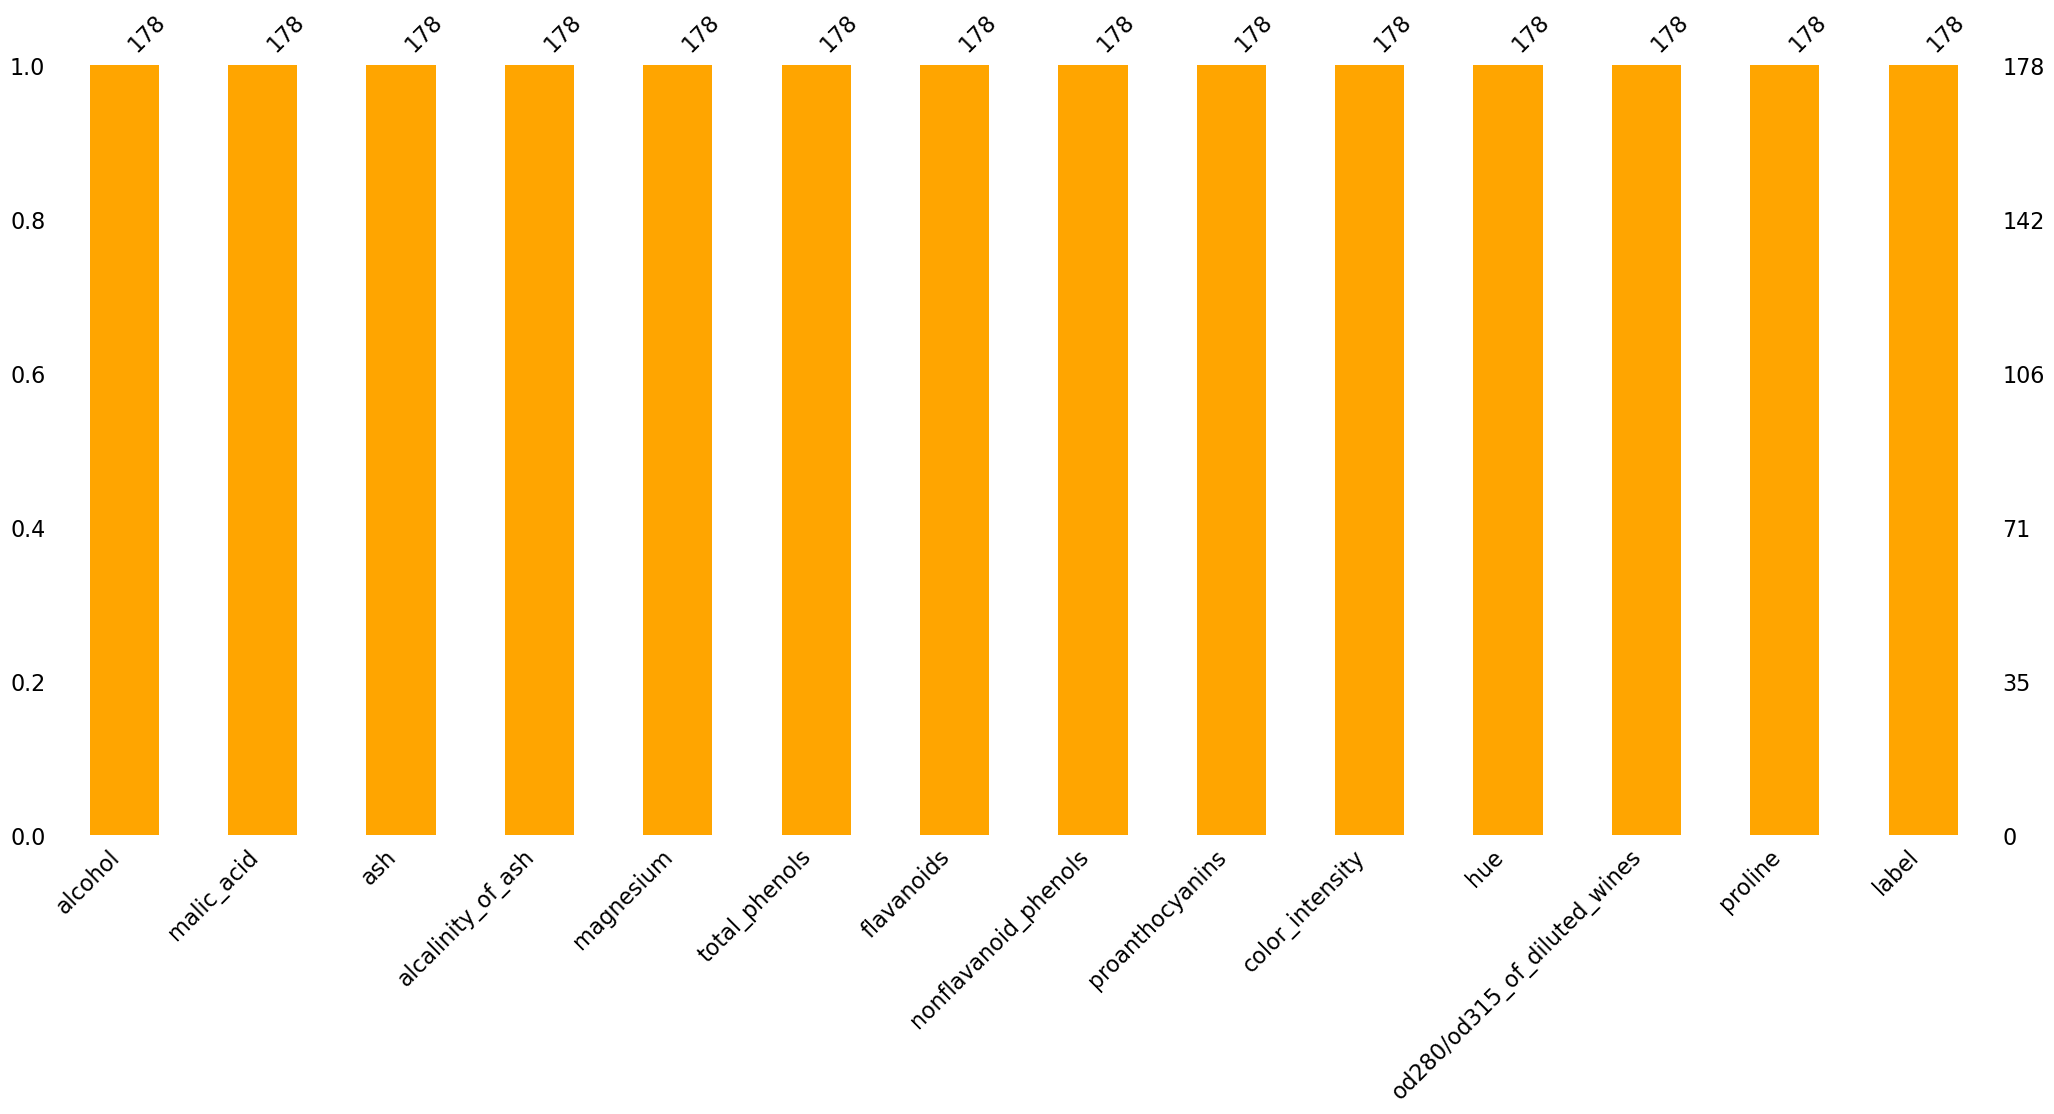

In [15]:
!pip install missingno
df.info()
import missingno as msno
msno.bar(df,color='orange')

To verify correlation between features we'll also plot a heatmap of the linear correlations (dataframe.corr()):

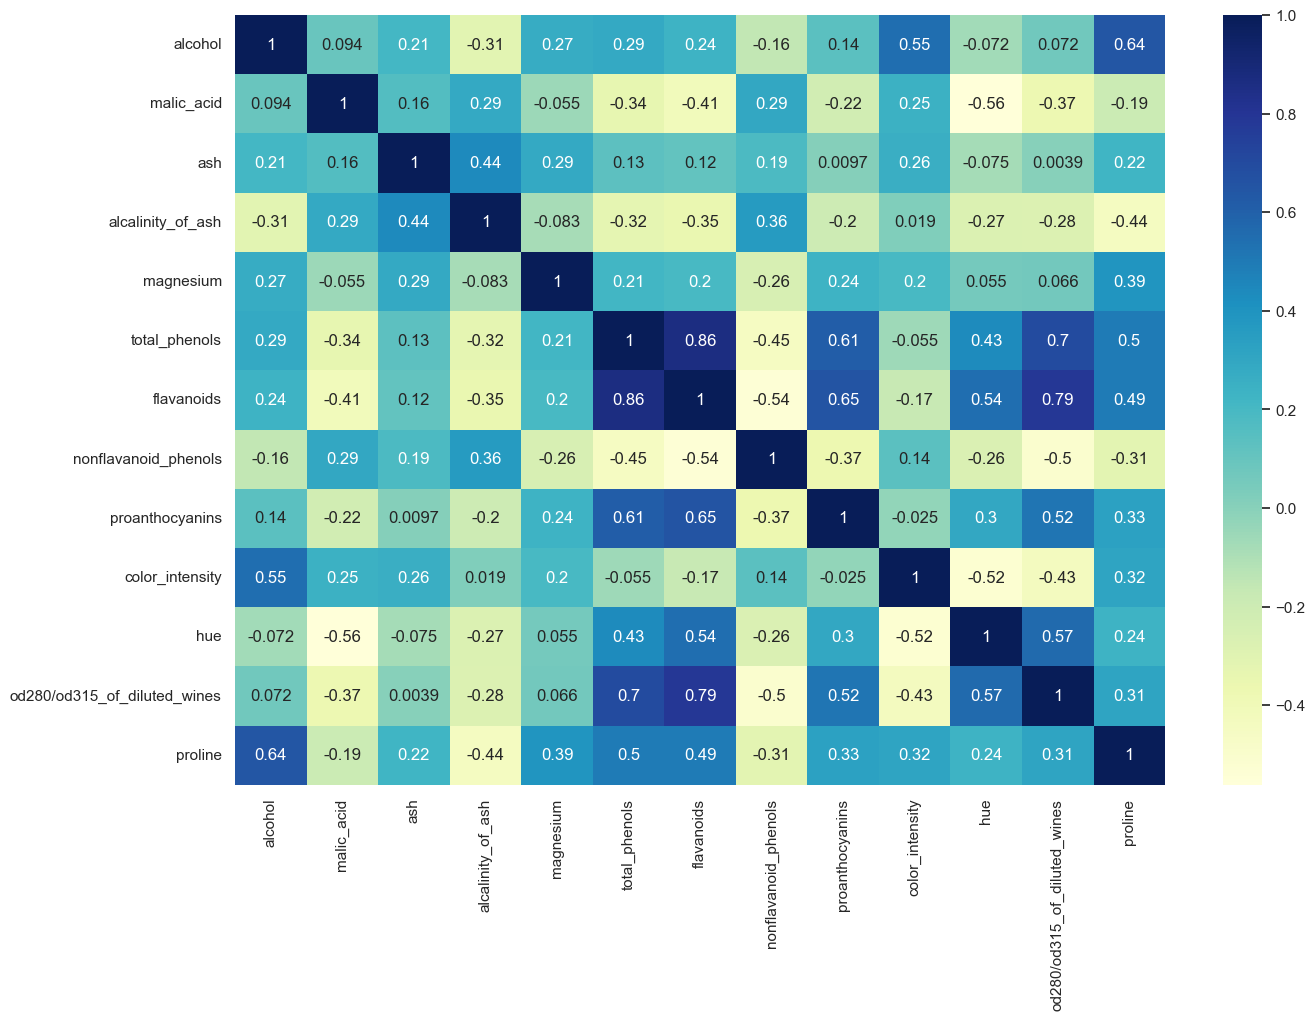

In [16]:
import matplotlib.pyplot as plt
import seaborn as sb
sb.set(rc={'figure.figsize':(15,10)})
sb.heatmap(df.iloc[:,:-1].corr(), annot=True, cmap='YlGnBu')
plt.show()

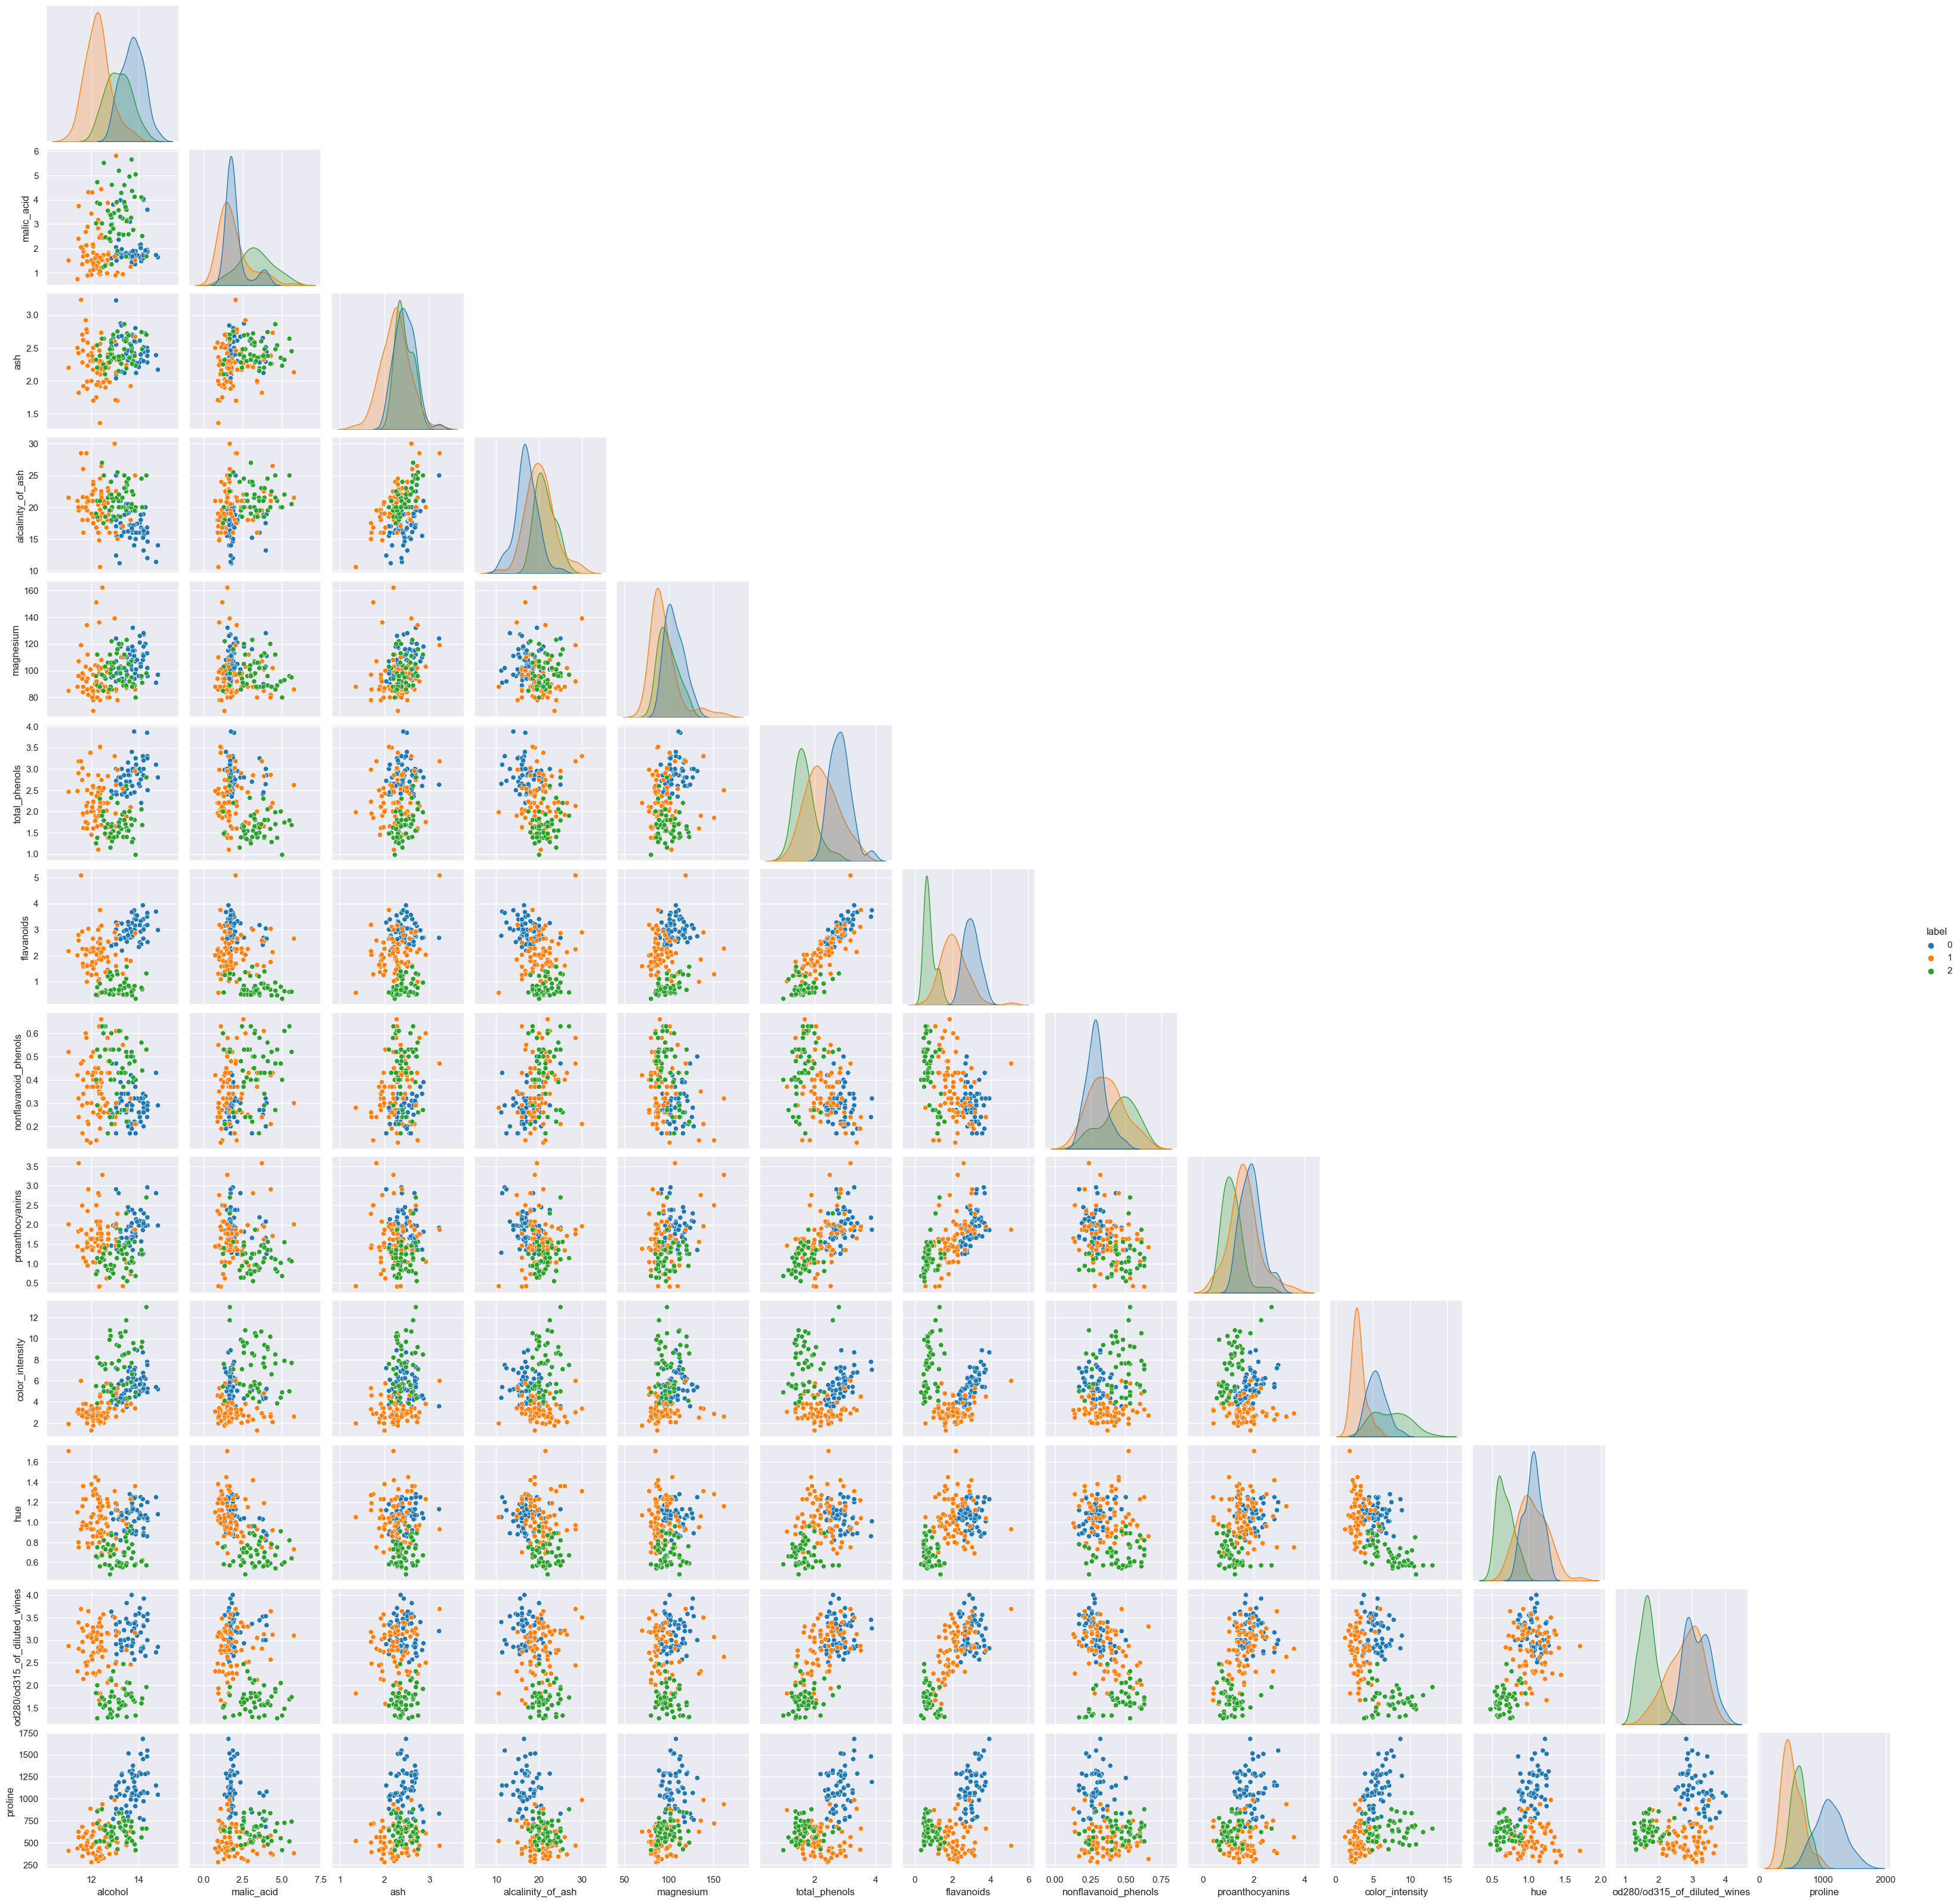

In [17]:
sb.pairplot(df, 
             hue='label', 
             palette="tab10", 
             corner=True)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(wdata.data,wdata.target,test_size=0.25)

In [19]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
gmodel = GaussianNB()
gmodel.fit(X_train,y_train)

GaussianNB()

In [20]:
gmodel.score(X_test,y_test)

0.9777777777777777

In [21]:
mn_model = MultinomialNB()
mn_model.fit(X_train,y_train)

MultinomialNB()

In [22]:
mn_model.score(X_test,y_test)

0.9555555555555556